<a href="https://colab.research.google.com/github/Titankhoa/ThucHanhXuLyAnhSo/blob/main/2174802010805_HongDangKhoa_243_NMXLAS_0102.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Câu 1 (2 điểm): Cho một ảnh bất kỳ (tên ảnh do sinh viên tự đặt, ví dụ: `my_image.jpg`) và thực hiện các yêu cầu sau:


Viết chương trình sử dụng Bilateral filter để làm mịn ảnh. (0.5 điểm)  

In [16]:
from google.colab import files
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
print(f"Ảnh bạn đã upload: {image_name}")


Saving a.jpg to a (1).jpg
Ảnh bạn đã upload: a (1).jpg


In [20]:
import cv2
import os

# Đọc ảnh
image = cv2.imread(image_name)

if image is None:
    print("Không đọc được ảnh! Kiểm tra lại file.")
else:
    base_name = os.path.splitext(os.path.basename(image_name))[0]

    # Viết chương trình sử dụng Bilateral filter để làm mịn ảnh. (0.5 điểm)
    bilateral = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)
    cv2.imwrite(f'{base_name}_bilateral.jpg', bilateral)

    # iết chương trình sử dụng Canny Edge Detection để xác định biên của hình ảnh. (0.5 điểm)
    edges = cv2.Canny(image, threshold1=100, threshold2=200)
    cv2.imwrite(f'{base_name}_edges.jpg', edges)

    # Đổi màu ảnh bằng cách hoán đổi kênh màu theo thứ tự (ví dụ: BGR → BRG) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm)
    swapped = image.copy()
    swapped[:, :, [0, 1, 2]] = swapped[:, :, [0, 2, 1]]
    cv2.imwrite(f'{base_name}_swapped.jpg', swapped)

    # Chuyển ảnh sang không gian màu YCrCb và tách riêng 3 kênh Y, Cr, Cb, lưu thành ảnh grayscale tương ứng (`[ten_anh]_Y.jpg`, `[ten_anh]_Cr.jpg`, `[ten_anh]_Cb.jpg`). (0.5 điểm)
    ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(ycrcb)
    cv2.imwrite(f'{base_name}_Y.jpg', Y)
    cv2.imwrite(f'{base_name}_Cr.jpg', Cr)
    cv2.imwrite(f'{base_name}_Cb.jpg', Cb)

    print("Đã xử lý xong và lưu kết quả.")


✅ Đã xử lý xong và lưu kết quả.


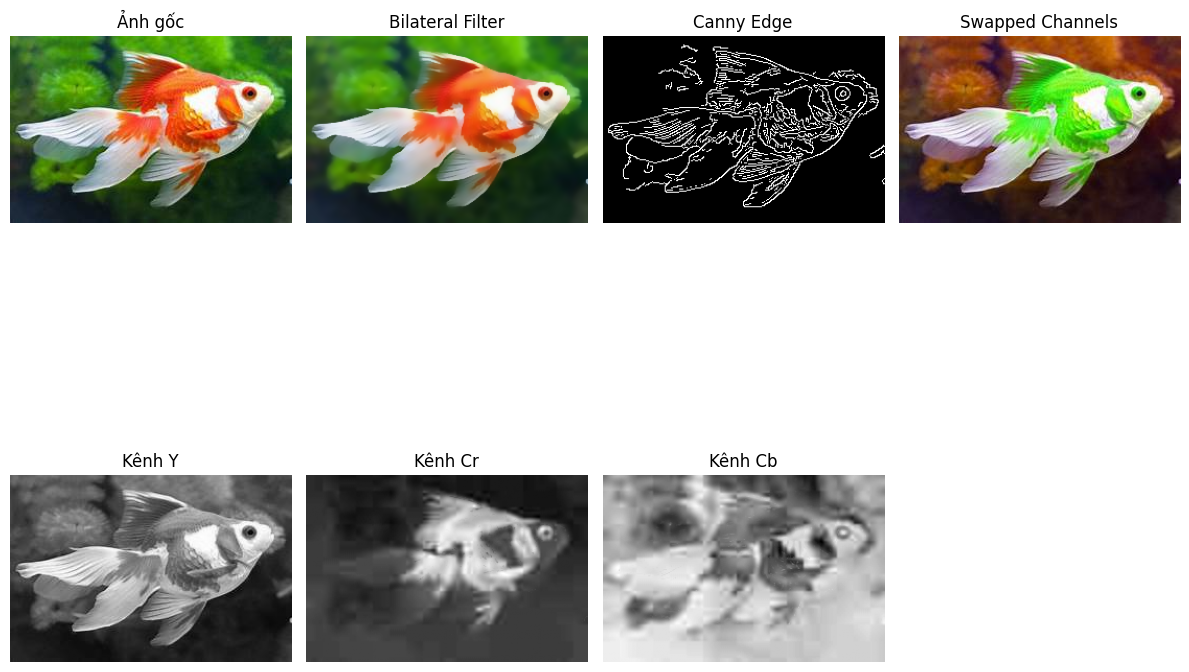

In [21]:
from matplotlib import pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB)
swapped_rgb = cv2.cvtColor(swapped, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 10))

plt.subplot(2, 4, 1)
plt.imshow(image_rgb)
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(bilateral_rgb)
plt.title('Bilateral Filter')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(swapped_rgb)
plt.title('Swapped Channels')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(Y, cmap='gray')
plt.title('Kênh Y')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(Cr, cmap='gray')
plt.title('Kênh Cr')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(Cb, cmap='gray')
plt.title('Kênh Cb')
plt.axis('off')

plt.tight_layout()
plt.show()


### Câu 2 (4 điểm) Viết một chương trình Python sử dụng OpenCV để tạo menu tương tác cho phép người dùng chọn các kỹ thuật biến đổi hình học và xử lý ảnh nâng cao từ một danh sách, áp dụng đồng thời cho nhiều ảnh.


In [23]:
#Upload 3 ảnh bất kỳ
from google.colab import files

uploaded = files.upload()
image_names = list(uploaded.keys())

#Kiểm tra đủ 3 file
if len(image_names) != 3:
    print(f"⚠️ Bạn chỉ upload {len(image_names)} file. Vui lòng upload đúng 3 file!")
else:
    print("Đã upload đủ 3 ảnh:")
    for i, name in enumerate(image_names, 1):
        print(f"{i}. {name}")


Saving image1.jpg to image1.jpg
Saving image2.jpg to image2.jpg
Saving image3.jpg to image3.jpg
✅ Đã upload đủ 3 ảnh:
1. image1.jpg
2. image2.jpg
3. image3.jpg


In [24]:
# Đọc ảnh
import cv2

images = []
for name in image_names:
    img = cv2.imread(name)
    if img is None:
        print(f" Không đọc được ảnh: {name}")
    else:
        images.append((name, img))

if len(images) != 3:
    print("⚠️ Không đọc đủ 3 ảnh. Thoát chương trình.")
else:
    print(" Đã đọc đủ 3 ảnh thành công!")


✅ Đã đọc đủ 3 ảnh thành công!


In [25]:
#Menu chọn kỹ thuật biến đổi và áp dụng đồng thời cho cả 3 ảnh
import os
import random

print("""
===== MENU =====
Nhập lựa chọn của bạn:
Z - Zoom (phóng to)
T - Rotate (xoay ảnh, góc ngẫu nhiên)
H - Horizontal Flip (lật ngang)
V - Vertical Flip (lật dọc)
C - Crop (cắt giữa)
P - Padding (thêm viền màu ngẫu nhiên)
================
""")

choice = input("Nhập lựa chọn (Z/T/H/V/C/P): ").strip().upper()

if choice not in ['Z', 'T', 'H', 'V', 'C', 'P']:
    print("Lựa chọn không hợp lệ! Vui lòng chạy lại.")
else:
    for name, img in images:
        base_name = os.path.splitext(os.path.basename(name))[0]
        result = None

        if choice == 'Z':
            # Phóng to 2 lần
            result = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)
            method = "zoom"

        elif choice == 'T':
            # Xoay góc ngẫu nhiên
            angle = random.randint(0, 360)
            (h, w) = img.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            result = cv2.warpAffine(img, M, (w, h))
            method = "rotate"

        elif choice == 'H':
            result = cv2.flip(img, 1)
            method = "hflip"

        elif choice == 'V':
            result = cv2.flip(img, 0)
            method = "vflip"

        elif choice == 'C':
            # Cắt giữa ảnh (1/2 kích thước gốc)
            (h, w) = img.shape[:2]
            start_x = w // 4
            start_y = h // 4
            end_x = start_x + w // 2
            end_y = start_y + h // 2
            result = img[start_y:end_y, start_x:end_x]
            method = "crop"

        elif choice == 'P':
            # Thêm viền màu ngẫu nhiên
            color = [random.randint(0, 255) for _ in range(3)]
            result = cv2.copyMakeBorder(img, 50, 50, 50, 50, cv2.BORDER_CONSTANT, value=color)
            method = "padding"

        # Lưu file kết quả
        output_name = f"result_{method}_{base_name}.jpg"
        cv2.imwrite(output_name, result)
        print(f"Đã lưu: {output_name}")



===== MENU =====
Nhập lựa chọn của bạn:
Z - Zoom (phóng to)
T - Rotate (xoay ảnh, góc ngẫu nhiên)
H - Horizontal Flip (lật ngang)
V - Vertical Flip (lật dọc)
C - Crop (cắt giữa)
P - Padding (thêm viền màu ngẫu nhiên)

Nhập lựa chọn (Z/T/H/V/C/P): Z
✅ Đã lưu: result_zoom_image1.jpg
✅ Đã lưu: result_zoom_image2.jpg
✅ Đã lưu: result_zoom_image3.jpg


### Câu 3 (4 điểm) Viết một chương trình Python để xử lý 3 ảnh bất kỳ do sinh viên tự chọn.

In [26]:
from google.colab import files

uploaded = files.upload()
image_names = list(uploaded.keys())

if len(image_names) != 3:
    print(f"Bạn chỉ upload {len(image_names)} file. Vui lòng upload đúng 3 file!")
else:
    print("Đã upload đủ 3 ảnh:")
    for i, name in enumerate(image_names, 1):
        print(f"{i}. {name}")


Saving image3.jpg to image3 (1).jpg
Saving image2.jpg to image2 (1).jpg
Saving image1.jpg to image1 (1).jpg
✅ Đã upload đủ 3 ảnh:
1. image3 (1).jpg
2. image2 (1).jpg
3. image1 (1).jpg


In [32]:
import cv2

images = []
for name in image_names:
    img = cv2.imread(name)
    if img is None:
        print(f"Không đọc được ảnh: {name}")
    else:
        images.append((name, img))

if len(images) != 3:
    print("Không đọc đủ 3 ảnh. Thoát chương trình.")
else:
    print("Đã đọc đủ 3 ảnh thành công!")


Đã đọc đủ 3 ảnh thành công!


In [33]:
import numpy as np
import os

# Thêm viền đen 20 pixel cho ảnh đầu tiên. (0.5 điểm)
name1, img1 = images[0]
bordered = cv2.copyMakeBorder(img1, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=(0, 0, 0))
cv2.imwrite('first_with_border.jpg', bordered)

# Xoay ảnh thứ hai 45 độ và phóng to 1.5 lần. (0.5 điểm)
name2, img2 = images[1]
(h, w) = img2.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.5)
rotated_scaled = cv2.warpAffine(img2, M, (w, h))
cv2.imwrite('second_rotated_scaled.jpg', rotated_scaled)

# Ảnh thứ ba:
name3, img3 = images[2]

# Tăng kích thước ảnh thứ ba lên 4 lần, sau đó áp dụng Bilateral Filter với tham số tùy chọn. (1.5 điểm)
resized = cv2.resize(img3, None, fx=4.0, fy=4.0, interpolation=cv2.INTER_LINEAR)

# Áp dụng Bilateral Filter (tham số tự chọn)
filtered = cv2.bilateralFilter(resized, d=9, sigmaColor=75, sigmaSpace=75)
cv2.imwrite('third_resized_filtered.jpg', filtered)

# Thay đổi độ sáng và độ tương phản ảnh thứ ba theo công thứ
alpha = 1.5  # Có thể thay đổi trong [0.6, 2.0]
beta = 40    # Có thể thay đổi trong [-60, 60]

adjusted = cv2.convertScaleAbs(filtered, alpha=alpha, beta=beta)
cv2.imwrite('third_brightness_contrast.jpg', adjusted)

print("Đã xử lý xong và lưu kết quả.")


Đã xử lý xong và lưu kết quả.


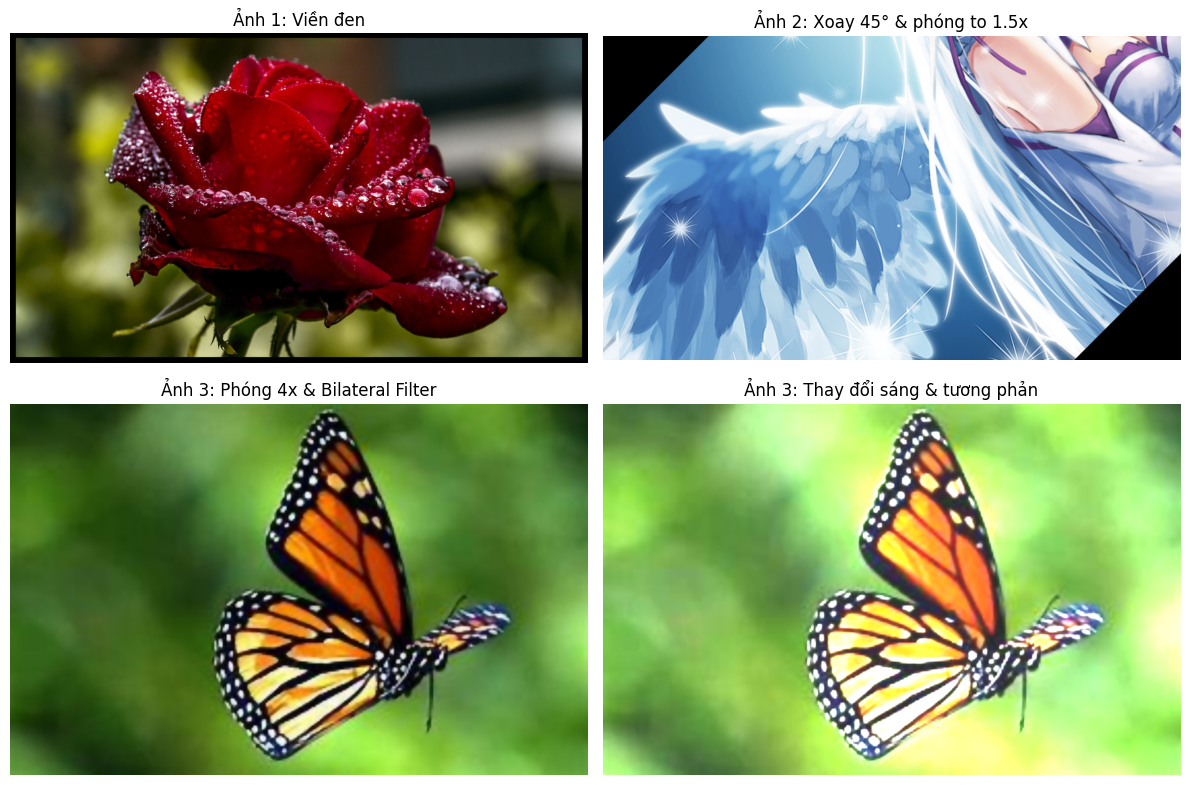

In [34]:
from matplotlib import pyplot as plt

# Chuyển đổi BGR -> RGB
bordered_rgb = cv2.cvtColor(bordered, cv2.COLOR_BGR2RGB)
rotated_scaled_rgb = cv2.cvtColor(rotated_scaled, cv2.COLOR_BGR2RGB)
filtered_rgb = cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB)
adjusted_rgb = cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(bordered_rgb)
plt.title('Ảnh 1: Viền đen')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(rotated_scaled_rgb)
plt.title('Ảnh 2: Xoay 45° & phóng to 1.5x')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(filtered_rgb)
plt.title('Ảnh 3: Phóng 4x & Bilateral Filter')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(adjusted_rgb)
plt.title('Ảnh 3: Thay đổi sáng & tương phản')
plt.axis('off')

plt.tight_layout()
plt.show()
